##### Copyright 2025 Google LLC.

In [1]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Day 3 - Building an agent with LangGraph and the Gemini API

Welcome back to the Kaggle 5-day Generative AI course!

In this notebook, you will use [LangGraph](https://www.langchain.com/langgraph) to define a stateful graph-based application built on top of the Gemini API.

You will build a simulated cafe ordering system, called BaristaBot. It will provide a looping chat interface to customers where they can order cafe beverages using natural language, and you will build nodes to represent the cafe's live menu and the "back room" ordering system.

BaristaBot is used in other Gemini API demos, so if you are looking to explore something with a more minimal implementation, check out the [BaristaBot function calling example](https://github.com/google-gemini/cookbook/blob/main/examples/Agents_Function_Calling_Barista_Bot.ipynb) that implements a similar system using only the Gemini API Python SDK and function calling.

## **IMPORTANT!**

The app built in this notebook takes **user input** using a **text box** ([Python's `input`](https://docs.python.org/3/library/functions.html#input)). These are commented-out to ensure that you can use the `Run all` feature without interruption. Keep an eye out for the steps where you need to uncomment the `.invoke(...)` calls in order to interact with the app.

If you wish to save a version of this notebook with `Save and Run all`, you will need to **re-comment** the lines you commented-out to ensure that the notebook can run without human input.

## For help

**Common issues are covered in the [FAQ and troubleshooting guide](https://www.kaggle.com/code/markishere/day-0-troubleshooting-and-faqs).**

## Get set up

Start by installing and importing the LangGraph SDK and LangChain support for the Gemini API.

In [2]:
# Remove conflicting packages from the Kaggle base environment.
!pip uninstall -qqy kfp jupyterlab libpysal thinc spacy fastai ydata-profiling google-cloud-bigquery google-generativeai
# Install langgraph and the packages used in this lab.
!pip install -qU 'langgraph==0.3.21' 'langchain-google-genai==2.1.2' 'langgraph-prebuilt==0.1.7'

### Set up your API key

The `GOOGLE_API_KEY` environment variable can be set to automatically configure the underlying API. This works for both the official Gemini Python SDK and for LangChain/LangGraph. 

To run the following cell, your API key must be stored it in a [Kaggle secret](https://www.kaggle.com/discussions/product-feedback/114053) named `GOOGLE_API_KEY`.

If you don't already have an API key, you can grab one from [AI Studio](https://aistudio.google.com/app/apikey). You can find [detailed instructions in the docs](https://ai.google.dev/gemini-api/docs/api-key).

To make the key available through Kaggle secrets, choose `Secrets` from the `Add-ons` menu and follow the instructions to add your key or enable it for this notebook.

In [3]:
import os
from kaggle_secrets import UserSecretsClient

GOOGLE_API_KEY = UserSecretsClient().get_secret("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

If you received an error response along the lines of `No user secrets exist for kernel id ...`, then you need to add your API key via `Add-ons`, `Secrets` **and** enable it.

![Screenshot of the checkbox to enable GOOGLE_API_KEY secret](https://storage.googleapis.com/kaggle-media/Images/5gdai_sc_3.png)
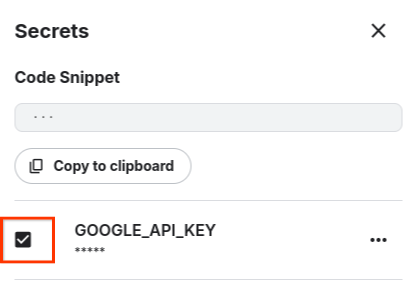

## Key concepts

LangGraph applications are built around a **graph** structure. As the developer, you define an application graph that models the state transitions for your application. Your app will define a **state** schema, and an instance of that schema is propagated through the graph.

Each **node** in the graph represents an action or step that can be taken. Nodes will make changes to the state in some way through code that you define. These changes can be the result of invoking an LLM, by calling an API, or executing any logic that the node defines.

Each **edge** in the graph represents a transition between states, defining the flow of the program. Edge transitions can be fixed, for example if you define a text-only chatbot where output is always displayed to a user, you may always transition from `chatbot -> user`. The transitions can also be conditional, allowing you to add branching (like an `if-else` statement) or looping (like `for` or `while` loops).

LangGraph is highly extensible and provides a number of features that are not part of this tutorial, such as memory, persistance and streaming. To better understand the key concepts and philophies behind LangGraph, check out their [Conceptual guides](https://langchain-ai.github.io/langgraph/concepts/) and [High-level overview](https://langchain-ai.github.io/langgraph/concepts/high_level/).

## Define core instructions

State is a fundamental concept for a LangGraph app. A state object is passed between every node and transition in the app. Here you define a state object, `OrderState`, that holds the conversation history, a structured order, and a flag indicating if the customer has finished placing their order. For simplicity, the "structure" in this order is just a list of strings, but this can be expanded to any Python data structure.

In Python, the LangGraph state object is a Python [dictionary](https://docs.python.org/3/library/stdtypes.html#dict). You can provide a schema for this dictionary by defining it as a [`TypedDict`](https://docs.python.org/3/library/typing.html#typing.TypedDict).

Here you also define the system instruction that the Gemini model will use. You can capture tone and style here, as well as the playbook under which the chatbot should operate.

In [4]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class OrderState(TypedDict):
    """State representing the customer's order conversation."""

    # The chat conversation. This preserves the conversation history
    # between nodes. The `add_messages` annotation indicates to LangGraph
    # that state is updated by appending returned messages, not replacing
    # them.
    messages: Annotated[list, add_messages]

    # The customer's in-progress order.
    order: list[str]

    # Flag indicating that the order is placed and completed.
    finished: bool


# The system instruction defines how the chatbot is expected to behave and includes
# rules for when to call different functions, as well as rules for the conversation, such
# as tone and what is permitted for discussion.
BARISTABOT_SYSINT = (
    "system",  # 'system' indicates the message is a system instruction.
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items (and only about "
    "menu items - no off-topic discussion, but you can chat about the products and their history). "
    "The customer will place an order for 1 or more items from the menu, which you will structure "
    "and send to the ordering system after confirming the order with the human. "
    "\n\n"
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "To see the contents of the order so far, call get_order (this is shown to you, not the user) "
    "Always confirm_order with the user (double-check) before calling place_order. Calling confirm_order will "
    "display the order items to the user and returns their response to seeing the list. Their response may contain modifications. "
    "Always verify and respond with drink and modifier names from the MENU before adding them to the order. "
    "If you are unsure a drink or modifier matches those on the MENU, ask a question to clarify or redirect. "
    "You only have the modifiers listed on the menu. "
    "Once the customer has finished ordering items, Call confirm_order to ensure it is correct then make "
    "any necessary updates and then call place_order. Once place_order has returned, thank the user and "
    "say goodbye!"
    "\n\n"
    "If any of the tools are unavailable, you can break the fourth wall and tell the user that "
    "they have not implemented them yet and should keep reading to do so.",
)

# This is the message with which the system opens the conversation.
WELCOME_MSG = "Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?"

## Define a single turn chatboot

To illustrate how LangGraph works, the following program defines a chatbot node that will execute a single turn in a chat conversation using the instructions supplied.

Each node in the graph operates on the state object. The state (a Python dictionary) is passed as a parameter into the node (a function) and the new state is returned. This can be restated as pseudo-code, where `state = node(state)`.

Note: For the `chatbot` node, the state is updated by *adding* the new conversation message. The `add_messages` annotation on `OrderState.messages` indicates that messages are *appended* when returned from a node. Typically state is updated by replacement, but this annotation causes `messages` to behave differently.

In [5]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

# Try using different models. The Gemini 2.0 flash model is highly
# capable, great with tools, and has a generous free tier. If you
# try the older 1.5 models, note that the `pro` models are better at
# complex multi-tool cases like this, but the `flash` models are
# faster and have more free quota.
# Check out the features and quota differences here:
#  - https://ai.google.dev/gemini-api/docs/models/gemini
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")


def chatbot(state: OrderState) -> OrderState:
    """The chatbot itself. A simple wrapper around the model's own chat interface."""
    message_history = [BARISTABOT_SYSINT] + state["messages"]
    return {"messages": [llm.invoke(message_history)]}


# Set up the initial graph based on our state definition.
graph_builder = StateGraph(OrderState)

# Add the chatbot function to the app graph as a node called "chatbot".
graph_builder.add_node("chatbot", chatbot)

# Define the chatbot node as the app entrypoint.
graph_builder.add_edge(START, "chatbot")

chat_graph = graph_builder.compile()

It can be helpful to visualise the graph you just defined. The following code renders the graph.

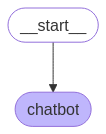

In [6]:
from IPython.display import Image

Image(chat_graph.get_graph().draw_mermaid_png())

Now that the graph is defined, you can run it. It only has one node, and one transition into that node, so it will transition from `__start__` to `chatbot`, execute the `chatbot` node, and terminate.

To run the graph, you call `invoke` and pass an initial state object. In this case it begins with the user's initial message.

In [7]:
user_msg = "Hello, what can you do?"
state = chat_graph.invoke({"messages": [user_msg]})

# The state object contains lots of information. Uncomment the pprint lines to see it all.
# pprint(state)

# Note that the final state now has 2 messages. Our HumanMessage, and an additional AIMessage.
for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: Hello, what can you do?
AIMessage: Hi there! I'm BaristaBot, ready to take your coffee order. I can tell you about our menu items, answer your questions, and put together your order. What are you in the mood for today?


You could execute this in a Python loop, but for simplicity, manually invoke one more conversational turn. This second invocation takes the state from the first call and appends another user message to elicit another response from the chatbot.

In [8]:
user_msg = "Oh great, what kinds of latte can you make?"

state["messages"].append(user_msg)
state = chat_graph.invoke(state)

# pprint(state)
for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: Hello, what can you do?
AIMessage: Hi there! I'm BaristaBot, ready to take your coffee order. I can tell you about our menu items, answer your questions, and put together your order. What are you in the mood for today?
HumanMessage: Oh great, what kinds of latte can you make?
AIMessage: We have a few delicious latte options:

*   **Latte:** Our classic espresso and steamed milk.
*   **Mocha Latte:** A chocolatey twist on the latte.
*   **Caramel Latte:** Sweet and smooth with caramel syrup.
*   **Vanilla Latte:** Infused with the sweet taste of vanilla.
*   **Iced Latte:** Our classic latte served over ice.

Which one sounds good to you? Or would you like to hear about our other drinks?


## Add a human node

Instead of repeatedly running the "graph" in a Python loop, you can use LangGraph to loop between nodes.

The `human` node will display the last message from the LLM to the user, and then prompt them for their next input. Here this is done using standard Python `print` and `input` functions, but for a real cafe situation, you could render the chat to a display or audio, and accept input from a mic or on-screen keyboard.

The `chatbot` node function has also been updated to include the welcome message to start the conversation.

In [9]:
from langchain_core.messages.ai import AIMessage


def human_node(state: OrderState) -> OrderState:
    """Display the last model message to the user, and receive the user's input."""
    last_msg = state["messages"][-1]
    print("Model:", last_msg.content)

    user_input = input("User: ")

    # If it looks like the user is trying to quit, flag the conversation
    # as over.
    if user_input in {"q", "quit", "exit", "goodbye"}:
        state["finished"] = True

    return state | {"messages": [("user", user_input)]}


def chatbot_with_welcome_msg(state: OrderState) -> OrderState:
    """The chatbot itself. A wrapper around the model's own chat interface."""

    if state["messages"]:
        # If there are messages, continue the conversation with the Gemini model.
        new_output = llm.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        # If there are no messages, start with the welcome message.
        new_output = AIMessage(content=WELCOME_MSG)

    return state | {"messages": [new_output]}


# Start building a new graph.
graph_builder = StateGraph(OrderState)

# Add the chatbot and human nodes to the app graph.
graph_builder.add_node("chatbot", chatbot_with_welcome_msg)
graph_builder.add_node("human", human_node)

# Start with the chatbot again.
graph_builder.add_edge(START, "chatbot")

# The chatbot will always go to the human next.
graph_builder.add_edge("chatbot", "human");

Before you can run this, note that if you added an edge from `human` back to `chatbot`, the graph will cycle forever as there is no exit condition. One way to break the cycle is to add a check for a human input like `q` or `quit` and use that to break the loop.

In LangGraph, this is achieved with a conditional edge. This is similar to a regular graph transition, except a custom function is called to determine which edge to traverse.

Conditional edge functions take the state as input, and return a string representing the name of the node to which it will transition.

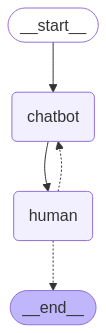

In [10]:
from typing import Literal


def maybe_exit_human_node(state: OrderState) -> Literal["chatbot", "__end__"]:
    """Route to the chatbot, unless it looks like the user is exiting."""
    if state.get("finished", False):
        return END
    else:
        return "chatbot"


graph_builder.add_conditional_edges("human", maybe_exit_human_node)

chat_with_human_graph = graph_builder.compile()

Image(chat_with_human_graph.get_graph().draw_mermaid_png())

Run this new graph to see how the interaction loop is now captured within the graph. Input `quit` to exit the program.

**You must uncomment the `.invoke(...)` line to run this step.**

In [11]:
# The default recursion limit for traversing nodes is 25 - setting it higher means
# you can try a more complex order with multiple steps and round-trips (and you
# can chat for longer!)
config = {"recursion_limit": 100}

# Remember that this will loop forever, unless you input `q`, `quit` or one of the
# other exit terms defined in `human_node`.
# Uncomment this line to execute the graph:
# state = chat_with_human_graph.invoke({"messages": []}, config)

# Things to try:
#  - Just chat! There's no ordering or menu yet.
#  - 'q' to exit.

# pprint(state)

## Add a "live" menu

BaristaBot currently has no awareness of the available items at the cafe, so it will hallucinate a menu. One option would be to hard-code a menu into the system prompt. This would work well, but to simulate a system where the menu is more dynamic and could respond to fluctuating stock levels, you will put the menu into a custom tool.

There are two types of tools that this system will use. Stateless tools that can be run automatically, and stateful tools that modify the order. The "get current menu" tool is stateless, in that it does not make any changes to the live order, so it can be called automatically.

In a LangGraph app, you can annotate Python functions as tools by applying the `@tools` annotation.



In [12]:
from langchain_core.tools import tool


@tool
def get_menu() -> str:
    """Provide the latest up-to-date menu."""
    # Note that this is just hard-coded text, but you could connect this to a live stock
    # database, or you could use Gemini's multi-modal capabilities and take live photos of
    # your cafe's chalk menu or the products on the counter and assmble them into an input.

    return """
    MENU:
    Coffee Drinks:
    Espresso
    Americano
    Cold Brew

    Coffee Drinks with Milk:
    Latte
    Cappuccino
    Cortado
    Macchiato
    Mocha
    Flat White

    Tea Drinks:
    English Breakfast Tea
    Green Tea
    Earl Grey

    Tea Drinks with Milk:
    Chai Latte
    Matcha Latte
    London Fog

    Other Drinks:
    Steamer
    Hot Chocolate

    Modifiers:
    Milk options: Whole, 2%, Oat, Almond, 2% Lactose Free; Default option: whole
    Espresso shots: Single, Double, Triple, Quadruple; default: Double
    Caffeine: Decaf, Regular; default: Regular
    Hot-Iced: Hot, Iced; Default: Hot
    Sweeteners (option to add one or more): vanilla sweetener, hazelnut sweetener, caramel sauce, chocolate sauce, sugar free vanilla sweetener
    Special requests: any reasonable modification that does not involve items not on the menu, for example: 'extra hot', 'one pump', 'half caff', 'extra foam', etc.

    "dirty" means add a shot of espresso to a drink that doesn't usually have it, like "Dirty Chai Latte".
    "Regular milk" is the same as 'whole milk'.
    "Sweetened" means add some regular sugar, not a sweetener.

    Soy milk has run out of stock today, so soy is not available.
  """

Now add the new tool to the graph. The `get_menu` tool is wrapped in a [`ToolNode`](https://langchain-ai.github.io/langgraph/reference/prebuilt/#toolnode) that handles calling the tool and passing the response as a message through the graph. The tools are also bound to the `llm` object so that the underlying model knows they exist. As you now have a different `llm` object to invoke, you need to update the `chatbot` node so that it is aware of the tools.


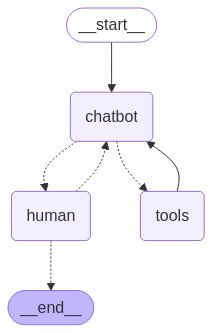

In [13]:
from langgraph.prebuilt import ToolNode


# Define the tools and create a "tools" node.
tools = [get_menu]
tool_node = ToolNode(tools)

# Attach the tools to the model so that it knows what it can call.
llm_with_tools = llm.bind_tools(tools)


def maybe_route_to_tools(state: OrderState) -> Literal["tools", "human"]:
    """Route between human or tool nodes, depending if a tool call is made."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    # Only route based on the last message.
    msg = msgs[-1]

    # When the chatbot returns tool_calls, route to the "tools" node.
    if hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        return "tools"
    else:
        return "human"


def chatbot_with_tools(state: OrderState) -> OrderState:
    """The chatbot with tools. A simple wrapper around the model's own chat interface."""
    defaults = {"order": [], "finished": False}

    if state["messages"]:
        new_output = llm_with_tools.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)

    # Set up some defaults if not already set, then pass through the provided state,
    # overriding only the "messages" field.
    return defaults | state | {"messages": [new_output]}


graph_builder = StateGraph(OrderState)

# Add the nodes, including the new tool_node.
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)

# Chatbot may go to tools, or human.
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
# Human may go back to chatbot, or exit.
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

# Tools always route back to chat afterwards.
graph_builder.add_edge("tools", "chatbot")

graph_builder.add_edge(START, "chatbot")
graph_with_menu = graph_builder.compile()

Image(graph_with_menu.get_graph().draw_mermaid_png())

Now run the new graph to see how the model uses the menu.

**You must uncomment the `.invoke(...)` line to run this step.**

In [14]:
# Remember that you have not implemented ordering yet, so this will loop forever,
# unless you input `q`, `quit` or one of the other exit terms defined in the
# `human_node`.
# Uncomment this line to execute the graph:
# state = graph_with_menu.invoke({"messages": []}, config)

# Things to try:
# - I'd love an espresso drink, what have you got?
# - What teas do you have?
# - Can you do a long black? (this is on the menu as an "Americano" - see if it can
#   figure it out)
# - 'q' to exit.


# pprint(state)

In [15]:
# Remember that you have not implemented ordering yet, so this will loop forever,
# unless you input `q`, `quit` or one of the other exit terms defined in the
# `human_node`.
# Uncomment this line to execute the graph:
# state = graph_with_menu.invoke({"messages": []}, config)

# Things to try:
# - I'd love an espresso drink, what have you got?
# - What teas do you have?
# - Can you do a long black? (this is on the menu as an "Americano" - see if it can
#   figure it out)
# - 'q' to exit.


# pprint(state)

## Handle orders

To build up an order during the chat conversation, you will need to update the state to track the order, and provide simple tools that update this state. These need to be explicit as the model should not directly have access to the apps internal state, or it risks being manipulated arbitrarily.

The ordering tools will be added as stubs in a separate node so that you can edit the state directly. Using the `@tool` annotation is still a handy way to define their schema, so the ordering tools below are implemented as empty Python functions.

In [16]:
from collections.abc import Iterable
from random import randint

from langchain_core.messages.tool import ToolMessage

# These functions have no body; LangGraph does not allow @tools to update
# the conversation state, so you will implement a separate node to handle
# state updates. Using @tools is still very convenient for defining the tool
# schema, so empty functions have been defined that will be bound to the LLM
# but their implementation is deferred to the order_node.


@tool
def add_to_order(drink: str, modifiers: Iterable[str]) -> str:
    """Adds the specified drink to the customer's order, including any modifiers.

    Returns:
      The updated order in progress.
    """


@tool
def confirm_order() -> str:
    """Asks the customer if the order is correct.

    Returns:
      The user's free-text response.
    """


@tool
def get_order() -> str:
    """Returns the users order so far. One item per line."""


@tool
def clear_order():
    """Removes all items from the user's order."""


@tool
def place_order() -> int:
    """Sends the order to the barista for fulfillment.

    Returns:
      The estimated number of minutes until the order is ready.
    """


def order_node(state: OrderState) -> OrderState:
    """The ordering node. This is where the order state is manipulated."""
    tool_msg = state.get("messages", [])[-1]
    order = state.get("order", [])
    outbound_msgs = []
    order_placed = False

    for tool_call in tool_msg.tool_calls:
        if tool_call["name"] == "add_to_order":
            # Each order item is just a string. This is where it assembled as "drink (modifiers, ...)".
            modifiers = tool_call["args"]["modifiers"]
            modifier_str = ", ".join(modifiers) if modifiers else "no modifiers"

            order.append(f"{tool_call['args']['drink']} ({modifier_str})")
            response = "\n".join(order)

        elif tool_call["name"] == "confirm_order":
            # We could entrust the LLM to do order confirmation, but it is a good practice to
            # show the user the exact data that comprises their order so that what they confirm
            # precisely matches the order that goes to the kitchen - avoiding hallucination
            # or reality skew.

            # In a real scenario, this is where you would connect your POS screen to show the
            # order to the user.

            print("Your order:")
            if not order:
                print("  (no items)")

            for drink in order:
                print(f"  {drink}")

            response = input("Is this correct? ")

        elif tool_call["name"] == "get_order":
            response = "\n".join(order) if order else "(no order)"

        elif tool_call["name"] == "clear_order":
            order.clear()
            response = None

        elif tool_call["name"] == "place_order":
            order_text = "\n".join(order)
            print("Sending order to kitchen!")
            print(order_text)

            # TODO(you!): Implement cafe.
            order_placed = True
            response = randint(1, 5)  # ETA in minutes

        else:
            raise NotImplementedError(f"Unknown tool call: {tool_call['name']}")

        # Record the tool results as tool messages.
        outbound_msgs.append(
            ToolMessage(
                content=response,
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": outbound_msgs, "order": order, "finished": order_placed}


def maybe_route_to_tools(state: OrderState) -> str:
    """Route between chat and tool nodes if a tool call is made."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    msg = msgs[-1]

    if state.get("finished", False):
        # When an order is placed, exit the app. The system instruction indicates
        # that the chatbot should say thanks and goodbye at this point, so we can exit
        # cleanly.
        return END

    elif hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        # Route to `tools` node for any automated tool calls first.
        if any(tool["name"] in tool_node.tools_by_name.keys() for tool in msg.tool_calls):
            return "tools"
        else:
            return "ordering"

    else:
        return "human"

Now define the graph. The LLM needs to know about the tools too, so that it can invoke them. Here you set up 2 sets of tools corresponding to the nodes under which they operate: automated and ordering.

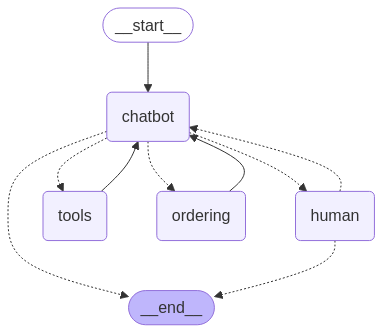

In [17]:
# Auto-tools will be invoked automatically by the ToolNode
auto_tools = [get_menu]
tool_node = ToolNode(auto_tools)

# Order-tools will be handled by the order node.
order_tools = [add_to_order, confirm_order, get_order, clear_order, place_order]

# The LLM needs to know about all of the tools, so specify everything here.
llm_with_tools = llm.bind_tools(auto_tools + order_tools)


graph_builder = StateGraph(OrderState)

# Nodes
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("ordering", order_node)

# Chatbot -> {ordering, tools, human, END}
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
# Human -> {chatbot, END}
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

# Tools (both kinds) always route back to chat afterwards.
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("ordering", "chatbot")

graph_builder.add_edge(START, "chatbot")
graph_with_order_tools = graph_builder.compile()

Image(graph_with_order_tools.get_graph().draw_mermaid_png())

Now run the complete ordering system graph.

**You must uncomment the `.invoke(...)` line to run this step.**

In [18]:
# Uncomment this line to execute the graph:
# state = graph_with_order_tools.invoke({"messages": []}, config)

# Things to try:
# - Order a drink!
# - Make a change to your order.
# - "Which teas are from England?"
# - Note that the graph should naturally exit after placing an order.

# pprint(state)

The order state has been captured both in the `place_order` function and in the final conversational state returned from executing the graph. This iillustrates how you can integrate your own systems to a graph app, as well as collect the final results of executing such an app.

In [19]:
# Uncomment this once you have run the graph from the previous cell.
# pprint(state["order"])

## Further exercises

Congratulations on building an agentic, human-in-the-loop, natural-language powered cafe ordering system using LangGraph and the Gemini API!

This example app could be taken in many different directions. You should try and build out your own ideas, but for some inspiration, consider:

* Adding more structure the order (`OrderState.order`) - e.g. separate fields for item, modifiers and even quantity.
* Currently the model can only clear and re-add items, so add a function to `remove_item`s from the order.
* Try building a UI that displays the in-progress order and hosts the chat. Frameworks like [Gradio](https://www.gradio.app/) or [Mesop](https://google.github.io/mesop/) are great for this.

This system works well for a single person ordering, but agentic systems can interact with many sources. For a big stretch exercise, try and extend this app to run at a specific schedule, and contact your friends or colleagues over [Chat](https://developers.google.com/workspace/chat/api/reference/rest) to collect their daily coffee orders.

*- [Mark McD](https://linktr.ee/markmcd)*

## exercise 1

- `remove_item` 추가

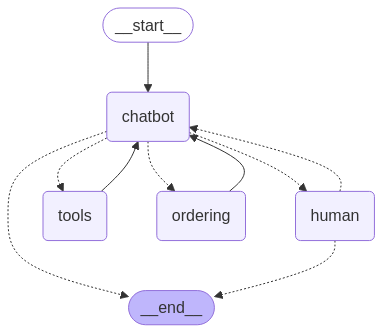

In [20]:
from collections.abc import Iterable


# These functions have no body; LangGraph does not allow @tools to update
# the conversation state, so you will implement a separate node to handle
# state updates. Using @tools is still very convenient for defining the tool
# schema, so empty functions have been defined that will be bound to the LLM
# but their implementation is deferred to the order_node.


@tool
def add_to_order(drink: str, modifiers: Iterable[str]) -> str:
    """Adds the specified drink to the customer's order, including any modifiers.

    Returns:
      The updated order in progress.
    """


@tool
def confirm_order() -> str:
    """Asks the customer if the order is correct.

    Returns:
      The user's free-text response.
    """


@tool
def get_order() -> str:
    """Returns the users order so far. One item per line."""


@tool
def clear_order():
    """Removes all items from the user's order."""


@tool
def place_order() -> int:
    """Sends the order to the barista for fulfillment.

    Returns:
      The estimated number of minutes until the order is ready.
    """


# 새로운 도구 추가
@tool
def remove_item(index: int) -> str:
    """고객의 주문에서 특정 항목을 제거합니다.

    Args:
        index: 제거할 항목의 인덱스 (1부터 시작)

    Returns:
        업데이트 된 주문 목록
    """


def order_node(state: OrderState) -> OrderState:
    """The ordering node. This is where the order state is manipulated."""
    tool_msg = state.get("messages", [])[-1]
    order = state.get("order", [])
    outbound_msgs = []
    order_placed = False

    for tool_call in tool_msg.tool_calls:
        if tool_call["name"] == "add_to_order":
            # Each order item is just a string. This is where it assembled as "drink (modifiers, ...)".
            modifiers = tool_call["args"]["modifiers"]
            modifier_str = ", ".join(modifiers) if modifiers else "no modifiers"

            order.append(f"{tool_call['args']['drink']} ({modifier_str})")
            response = "\n".join([f"{i + 1}. {item}" for i, item in enumerate(order)])

        elif tool_call["name"] == "confirm_order":
            # We could entrust the LLM to do order confirmation, but it is a good practice to
            # show the user the exact data that comprises their order so that what they confirm
            # precisely matches the order that goes to the kitchen - avoiding hallucination
            # or reality skew.

            # In a real scenario, this is where you would connect your POS screen to show the
            # order to the user.

            print("Your order:")
            if not order:
                print("  (no items)")
            else:
                for i, drink in enumerate(order, 1):
                    print(f"  {i}. {drink}")

            response = input("Is this correct? ")

        elif tool_call["name"] == "get_order":
            response = "\n".join([f"{i + 1}. {item}" for i, item in enumerate(order)]) if order else "(no order)"

        elif tool_call["name"] == "clear_order":
            order.clear()
            response = None

        # 새로운 도구 구현: remove_item (오류 수정)
        elif tool_call["name"] == "remove_item":
            try:
                index = int(tool_call["args"]["index"])  # 명시적으로 정수로 변환

                if not order:
                    response = "주문이 비어 있습니다."
                elif index < 1 or index > len(order):
                    response = f"유효하지 않은 인덱스입니다. 1부터 {len(order)}까지의 숫자를 입력하세요."
                else:
                    removed_item = order.pop(index - 1)  # 1부터 시작하는 인덱스를 0부터 시작하는 인덱스로 변환
                    if order:
                        response = f"'{removed_item}'이(가) 주문에서 제거되었습니다.\n" + "\n".join(
                            [f"{i + 1}. {item}" for i, item in enumerate(order)]
                        )
                    else:
                        response = f"'{removed_item}'이(가) 주문에서 제거되었습니다. 주문이 비어 있습니다."
            except (ValueError, TypeError):
                # 변환 실패 시 처리
                response = "유효하지 않은 인덱스입니다. 숫자를 입력해주세요."

        elif tool_call["name"] == "place_order":
            order_text = "\n".join(order)
            print("Sending order to kitchen!")
            print(order_text)

            # TODO(you!): Implement cafe.
            order_placed = True
            response = randint(1, 5)  # ETA in minutes

        else:
            raise NotImplementedError(f"Unknown tool call: {tool_call['name']}")

        # Record the tool results as tool messages.
        outbound_msgs.append(
            ToolMessage(
                content=response,
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": outbound_msgs, "order": order, "finished": order_placed}


def maybe_route_to_tools(state: OrderState) -> str:
    """Route between chat and tool nodes if a tool call is made."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    msg = msgs[-1]

    if state.get("finished", False):
        # When an order is placed, exit the app. The system instruction indicates
        # that the chatbot should say thanks and goodbye at this point, so we can exit
        # cleanly.
        return END

    elif hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        # Route to `tools` node for any automated tool calls first.
        if any(tool["name"] in tool_node.tools_by_name.keys() for tool in msg.tool_calls):
            return "tools"
        else:
            return "ordering"

    else:
        return "human"


# Auto-tools will be invoked automatically by the ToolNode
auto_tools = [get_menu]
tool_node = ToolNode(auto_tools)

# Order-tools will be handled by the order node.
order_tools = [add_to_order, confirm_order, get_order, clear_order, place_order, remove_item]

# The LLM needs to know about all of the tools, so specify everything here.
llm_with_tools = llm.bind_tools(auto_tools + order_tools)


graph_builder = StateGraph(OrderState)

# Nodes
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("ordering", order_node)

# Chatbot -> {ordering, tools, human, END}
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
# Human -> {chatbot, END}
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

# Tools (both kinds) always route back to chat afterwards.
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("ordering", "chatbot")

graph_builder.add_edge(START, "chatbot")
graph_with_order_tools = graph_builder.compile()

Image(graph_with_order_tools.get_graph().draw_mermaid_png())

# 변경 사항 요약:
# 오류 수정: remove_item 도구에서 인덱스 값을 명시적으로 정수로 변환하고, 실패 시 예외를 처리했습니다.
# 번호 매기기 개선: 주문 목록을 반환하거나 보여줄 때 숫자를 표시하도록 get_order, add_to_order, confirm_order 함수를 업데이트했습니다.
# 오류 메시지 개선: 유효하지 않은 인덱스나 비어 있는 주문에 대한 더 명확한 피드백을 제공합니다.
# 이제 사용자가 "첫 번째 항목을 삭제해 주세요"와 같은 요청을 할 때 더 안정적으로 작동할 것입니다

# 추가: confirm 에서 else문 추가
# 실행 시점 이슈: if not order 조건이 평가될 때와 for 루프가 실행될 때 사이에 무언가 발생했을 수 있습니다. else 절을 사용하면 두 부분이 논리적으로 함께 묶여 일관되게 실행됩니다.
# 비동기 처리: LangGraph가 비동기적으로 작동하기 때문에, if 조건 평가 후 for 루프 실행 전에 다른 비동기 작업이 끼어들어 상태를 변경했을 수 있습니다.
# 컨텍스트 변경: else 없이 작성된 코드는 if 블록과 이후의 for 루프가 별개의 실행 컨텍스트에서 처리될 여지가 있었을 수 있습니다.
# 이것은 매우 미묘한 문제이며, 특히 비동기적으로 작동하는 프레임워크에서 자주 발생합니다. else 절을 추가하여 두 부분을 논리적으로 묶음으로써 일관된 실행 컨텍스트가 보장된 것으로 보입니다.
# 이러한 작은 변화로 큰 차이가 발생하는 경우는 프로그래밍에서 종종 발생하며, 특히 복잡한 상태 관리가 필요한 애플리케이션에서 더욱 그렇습니다. 이런 경험은 코드 구조와 실행 흐름의 중요성을 잘 보여주는 좋은 예입니다.

In [21]:
# Uncomment this line to execute the graph:
# state = graph_with_order_tools.invoke({"messages": []}, config)

# Things to try:
# - Order a drink!
# - Make a change to your order.
# - "Which teas are from England?"
# - Note that the graph should naturally exit after placing an order.

# pprint(state)

## exercise 2

- 게임 구현해보기

In [22]:
# from typing import Annotated, List, Dict, Optional
# from typing_extensions import TypedDict
# from collections.abc import Iterable
# from random import randint, choice, random
# from datetime import datetime, timedelta

# from langchain_core.messages.tool import ToolMessage
# from langgraph.graph.message import add_messages

# # ======== 1. 게임 상태 정의 ========

# class MenuItem(TypedDict):
#     """메뉴 항목을 나타내는 클래스"""
#     name: str
#     price: float
#     prep_time: int  # 준비 시간(분)
#     ingredients: Dict[str, int]  # 재료와 필요한 양
#     category: str  # 음료 종류 (커피, 차, 스무디 등)

# class Customer(TypedDict):
#     """고객을 나타내는 클래스"""
#     name: str
#     patience: int  # 참을성 (1-10)
#     preferences: List[str]  # 선호하는 음료
#     satisfaction: int  # 만족도 (1-10)

# class CafeGameState(TypedDict):
#     """카페 게임 상태를 나타냅니다."""
#     # 기존 OrderState 요소 포함
#     messages: Annotated[list, add_messages]
#     order: list[str]
#     finished: bool

#     # 새로운 게임 요소
#     money: float  # 총 자금
#     menu_items: Dict[str, MenuItem]  # 메뉴 항목
#     inventory: Dict[str, int]  # 재고
#     day: int  # 게임 진행 일수
#     time: str  # 현재 시간 (아침, 오후, 저녁)
#     customers_served: int  # 오늘 서비스한 고객 수
#     reputation: int  # 카페 평판 (1-100)
#     staff: int  # 직원 수
#     daily_expenses: float  # 일일 고정 비용


# # ======== 2. 초기 게임 설정 ========

# def initialize_game() -> CafeGameState:
#     """게임 초기 상태를 설정합니다."""

#     # 메뉴 초기화
#     default_menu = {
#         "아메리카노": {
#             "name": "아메리카노",
#             "price": 4500.0,
#             "prep_time": 2,
#             "ingredients": {"커피 원두": 1, "물": 2},
#             "category": "커피"
#         },
#         "카페라떼": {
#             "name": "카페라떼",
#             "price": 5000.0,
#             "prep_time": 3,
#             "ingredients": {"커피 원두": 1, "우유": 2, "물": 1},
#             "category": "커피"
#         },
#         "카푸치노": {
#             "name": "카푸치노",
#             "price": 5500.0,
#             "prep_time": 4,
#             "ingredients": {"커피 원두": 1, "우유": 1, "물": 1, "우유 거품": 1},
#             "category": "커피"
#         },
#         "녹차": {
#             "name": "녹차",
#             "price": 4000.0,
#             "prep_time": 2,
#             "ingredients": {"녹차 잎": 1, "물": 2},
#             "category": "차"
#         },
#         "홍차": {
#             "name": "홍차",
#             "price": 4000.0,
#             "prep_time": 2,
#             "ingredients": {"홍차 잎": 1, "물": 2},
#             "category": "차"
#         },
#         "초콜릿 쿠키": {
#             "name": "초콜릿 쿠키",
#             "price": 3000.0,
#             "prep_time": 1,
#             "ingredients": {"쿠키": 1},
#             "category": "디저트"
#         }
#     }

#     # 초기 재고
#     initial_inventory = {
#         "커피 원두": 100,
#         "우유": 50,
#         "물": 500,
#         "우유 거품": 50,
#         "녹차 잎": 30,
#         "홍차 잎": 30,
#         "쿠키": 20
#     }

#     # 게임 초기 상태 반환
#     return {
#         "messages": [],
#         "order": [],
#         "finished": False,
#         "money": 100000.0,  # 초기 자금: 10만원
#         "menu_items": default_menu,
#         "inventory": initial_inventory,
#         "day": 1,
#         "time": "아침",
#         "customers_served": 0,
#         "reputation": 50,  # 평균적인 평판으로 시작
#         "staff": 1,  # 처음에는 혼자 일함 (플레이어)
#         "daily_expenses": 50000.0  # 일일 고정 비용 (임대료, 공과금 등)
#     }


# # ======== 3. 도구 정의 ========

# @tool
# def add_to_order(drink: str, modifiers: Iterable[str]) -> str:
#     """지정된 음료를 고객의 주문에 추가합니다.

#     Args:
#         drink: 추가할 음료 이름
#         modifiers: 수정자 목록 (예: 시럽 추가, 얼음 없음 등)

#     Returns:
#         업데이트된 주문 목록
#     """


# @tool
# def confirm_order() -> str:
#     """주문이 정확한지 고객에게 확인합니다.

#     Returns:
#         고객의 응답
#     """


# @tool
# def get_order() -> str:
#     """현재 주문 목록을 반환합니다."""


# @tool
# def clear_order():
#     """현재 주문을 모두 지웁니다."""


# @tool
# def remove_item(index: int) -> str:
#     """주문에서 항목을 제거합니다.

#     Args:
#         index: 제거할 항목의 인덱스 (1부터 시작)

#     Returns:
#         업데이트된 주문 목록
#     """


# @tool
# def place_order() -> str:
#     """주문을 처리하고 카페의 재고와 자금을 업데이트합니다.

#     Returns:
#         주문 처리 결과 (예상 대기 시간, 수익 등)
#     """


# @tool
# def check_menu() -> str:
#     """현재 카페 메뉴와 가격을 확인합니다.

#     Returns:
#         메뉴 목록
#     """


# @tool
# def check_inventory() -> str:
#     """현재 재고 상태를 확인합니다.

#     Returns:
#         재고 목록
#     """


# @tool
# def restock_inventory(item: str, amount: int) -> str:
#     """재고를 보충합니다.

#     Args:
#         item: 보충할 항목 이름
#         amount: 보충할 양

#     Returns:
#         재고 보충 결과
#     """


# @tool
# def check_finances() -> str:
#     """현재 카페의 재정 상태를 확인합니다.

#     Returns:
#         재정 정보 (현재 자금, 일일 수익/비용 등)
#     """


# @tool
# def advance_time() -> str:
#     """게임 시간을 진행합니다 (아침 -> 오후 -> 저녁 -> 다음 날 아침).

#     Returns:
#         새로운 시간 정보
#     """


# # ======== 4. 도구 구현 노드 ========

# def cafe_game_node(state: CafeGameState) -> CafeGameState:
#     """카페 게임의 상태를 관리하는 노드입니다."""
#     tool_msg = state.get("messages", [])[-1]
#     order = state.get("order", [])
#     money = state.get("money", 100000.0)
#     menu_items = state.get("menu_items", {})
#     inventory = state.get("inventory", {})
#     day = state.get("day", 1)
#     time_of_day = state.get("time", "아침")
#     customers_served = state.get("customers_served", 0)
#     reputation = state.get("reputation", 50)
#     staff = state.get("staff", 1)
#     daily_expenses = state.get("daily_expenses", 50000.0)

#     outbound_msgs = []
#     order_placed = False

#     for tool_call in tool_msg.tool_calls:

#         if tool_call["name"] == "add_to_order":
#             # 음료 추가
#             drink_name = tool_call["args"]["drink"]
#             modifiers = tool_call["args"]["modifiers"]
#             modifier_str = ", ".join(modifiers) if modifiers else "수정자 없음"

#             # 메뉴에 있는지 확인
#             menu_item = None
#             for item in menu_items.values():
#                 if item["name"].lower() == drink_name.lower():
#                     menu_item = item
#                     break

#             if menu_item:
#                 order.append(f'{drink_name} ({modifier_str})')
#                 response = "\n".join([f"{i+1}. {item}" for i, item in enumerate(order)])
#             else:
#                 response = f"죄송합니다. {drink_name}은(는) 메뉴에 없습니다."

#         elif tool_call["name"] == "confirm_order":
#             # 주문 확인
#             print("현재 주문:")
#             if not order:
#                 print("  (항목 없음)")
#             else:
#                 for i, drink in enumerate(order, 1):
#                     print(f"  {i}. {drink}")

#             response = input("이 주문이 맞습니까? ")

#         elif tool_call["name"] == "get_order":
#             # 현재 주문 조회
#             response = "\n".join([f"{i+1}. {item}" for i, item in enumerate(order)]) if order else "(주문 없음)"

#         elif tool_call["name"] == "clear_order":
#             # 주문 취소
#             order.clear()
#             response = "주문이 취소되었습니다."

#         elif tool_call["name"] == "remove_item":
#             # 항목 제거
#             try:
#                 index = int(tool_call["args"]["index"])

#                 if not order:
#                     response = "주문이 비어 있습니다."
#                 elif index < 1 or index > len(order):
#                     response = f"유효하지 않은 인덱스입니다. 1부터 {len(order)}까지의 숫자를 입력하세요."
#                 else:
#                     removed_item = order.pop(index - 1)
#                     if order:
#                         response = f"'{removed_item}'이(가) 주문에서 제거되었습니다.\n" + "\n".join([f"{i+1}. {item}" for i, item in enumerate(order)])
#                     else:
#                         response = f"'{removed_item}'이(가) 주문에서 제거되었습니다. 주문이 비어 있습니다."
#             except (ValueError, TypeError):
#                 response = "유효하지 않은 인덱스입니다. 숫자를 입력해주세요."

#         elif tool_call["name"] == "place_order":
#             # 주문 처리
#             if not order:
#                 response = "주문 항목이 없습니다. 먼저 음료를 추가해주세요."
#             else:
#                 # 주문 처리 로직
#                 total_cost = 0
#                 total_revenue = 0
#                 total_prep_time = 0
#                 enough_inventory = True
#                 needed_ingredients = {}

#                 for item_str in order:
#                     # 음료 이름 추출 (괄호 앞 부분)
#                     drink_name = item_str.split(" (")[0]

#                     # 메뉴에서 해당 음료 찾기
#                     menu_item = None
#                     for item in menu_items.values():
#                         if item["name"].lower() == drink_name.lower():
#                             menu_item = item
#                             break

#                     if menu_item:
#                         # 재고 확인 및 필요한 재료 누적
#                         for ingredient, amount in menu_item["ingredients"].items():
#                             if ingredient not in needed_ingredients:
#                                 needed_ingredients[ingredient] = 0
#                             needed_ingredients[ingredient] += amount

#                         # 수익과 준비 시간 계산
#                         total_revenue += menu_item["price"]
#                         total_prep_time = max(total_prep_time, menu_item["prep_time"])  # 동시에 준비 가능하다고 가정

#                 # 재고 충분한지 최종 확인
#                 for ingredient, amount in needed_ingredients.items():
#                     if ingredient not in inventory or inventory[ingredient] < amount:
#                         enough_inventory = False
#                         break

#                 if enough_inventory:
#                     # 재고 차감
#                     for ingredient, amount in needed_ingredients.items():
#                         inventory[ingredient] -= amount

#                     # 수익 계산 및 돈 추가
#                     profit = total_revenue - total_cost
#                     money += profit

#                     # 고객 서비스 통계 업데이트
#                     customers_served += 1

#                     # 평판 업데이트 (랜덤 요소 추가)
#                     satisfaction = randint(3, 10)  # 3-10 범위의 고객 만족도
#                     reputation_change = satisfaction - 5  # 5 이상이면 평판 상승
#                     reputation = max(0, min(100, reputation + reputation_change))

#                     # 응답 생성
#                     print("주문을 처리하는 중...")
#                     print("\n".join(order))

#                     order_placed = True
#                     response = f"주문이 접수되었습니다! 예상 준비 시간: {total_prep_time}분\n"
#                     response += f"매출: {total_revenue:,}원, 순이익: {profit:,}원"

#                     # 주문 완료 후 주문 목록 초기화
#                     order.clear()
#                 else:
#                     response = "재고가 부족합니다. 재고를 보충한 후 다시 시도해주세요."

#         elif tool_call["name"] == "check_menu":
#             # 메뉴 확인
#             menu_text = "==== 카페 메뉴 ====\n"

#             categories = {}
#             for item in menu_items.values():
#                 category = item["category"]
#                 if category not in categories:
#                     categories[category] = []
#                 categories[category].append(item)

#             for category, items in categories.items():
#                 menu_text += f"\n[ {category} ]\n"
#                 for item in items:
#                     menu_text += f"- {item['name']}: {item['price']:,}원\n"

#             response = menu_text

#         elif tool_call["name"] == "check_inventory":
#             # 재고 확인
#             inventory_text = "==== 현재 재고 ====\n"
#             for item, amount in inventory.items():
#                 inventory_text += f"- {item}: {amount}개\n"

#             response = inventory_text

#         elif tool_call["name"] == "restock_inventory":
#             # 재고 보충
#             item_name = tool_call["args"]["item"]
#             amount = int(tool_call["args"]["amount"])

#             if amount <= 0:
#                 response = "0보다 큰 수량을 입력해주세요."
#             else:
#                 # 아이템 가격 (임의 설정)
#                 item_costs = {
#                     "커피 원두": 200,
#                     "우유": 100,
#                     "물": 10,
#                     "우유 거품": 150,
#                     "녹차 잎": 150,
#                     "홍차 잎": 150,
#                     "쿠키": 500
#                 }

#                 if item_name in item_costs:
#                     cost = item_costs[item_name] * amount

#                     if money >= cost:
#                         # 재고 추가 및 비용 지불
#                         if item_name not in inventory:
#                             inventory[item_name] = 0
#                         inventory[item_name] += amount
#                         money -= cost

#                         response = f"{item_name} {amount}개를 {cost:,}원에 구매했습니다.\n"
#                         response += f"현재 {item_name} 재고: {inventory[item_name]}개\n"
#                         response += f"남은 자금: {money:,}원"
#                     else:
#                         response = f"자금이 부족합니다. 필요: {cost:,}원, 현재 보유: {money:,}원"
#                 else:
#                     response = f"{item_name}은(는) 구매할 수 없는 아이템입니다."

#         elif tool_call["name"] == "check_finances":
#             # 재정 확인
#             finances_text = "==== 카페 재정 상태 ====\n"
#             finances_text += f"현재 자금: {money:,}원\n"
#             finances_text += f"일일 고정 비용: {daily_expenses:,}원\n"
#             finances_text += f"직원 수: {staff}명\n"
#             finances_text += f"오늘 서비스한 고객 수: {customers_served}명\n"
#             finances_text += f"카페 평판: {reputation}/100"

#             response = finances_text

#         elif tool_call["name"] == "advance_time":
#             # 시간 진행
#             time_progression = {
#                 "아침": "오후",
#                 "오후": "저녁",
#                 "저녁": "마감"
#             }

#             if time_of_day in time_progression:
#                 time_of_day = time_progression[time_of_day]

#                 if time_of_day == "마감":
#                     # 하루 마감 처리
#                     # 일일 비용 계산
#                     total_daily_cost = daily_expenses + (staff * 8000)  # 직원 일당
#                     money -= total_daily_cost

#                     # 다음 날로 진행
#                     day += 1
#                     time_of_day = "아침"
#                     customers_served = 0  # 고객 수 초기화

#                     # 결과 텍스트 생성
#                     end_day_text = f"==== {day-1}일차 마감 ====\n"
#                     end_day_text += f"총 고객 수: {customers_served}명\n"
#                     end_day_text += f"일일 지출: {total_daily_cost:,}원\n"
#                     end_day_text += f"현재 자금: {money:,}원\n"
#                     end_day_text += f"카페 평판: {reputation}/100\n\n"
#                     end_day_text += f"==== {day}일차 시작 ====\n"
#                     end_day_text += "좋은 아침입니다! 오늘도 카페를 열 준비가 되었습니다."

#                     response = end_day_text
#                 else:
#                     response = f"시간이 진행되었습니다. 현재 시간: {time_of_day}"
#             else:
#                 response = "알 수 없는 시간대입니다."

#         else:
#             response = f"알 수 없는 도구 호출: {tool_call['name']}"

#         # 도구 결과를 메시지로 기록
#         outbound_msgs.append(
#             ToolMessage(
#                 content=response,
#                 name=tool_call["name"],
#                 tool_call_id=tool_call["id"],
#             )
#         )

#     # 업데이트된 상태 반환
#     return {
#         "messages": outbound_msgs,
#         "order": order,
#         "finished": order_placed,
#         "money": money,
#         "menu_items": menu_items,
#         "inventory": inventory,
#         "day": day,
#         "time": time_of_day,
#         "customers_served": customers_served,
#         "reputation": reputation,
#         "staff": staff,
#         "daily_expenses": daily_expenses
#     }

# # ======== 5. 시스템 지침 업데이트 ========

# CAFE_GAME_SYSINT = (
#     "system",
#     "당신은 카페 시뮬레이션 게임의 진행자입니다. 플레이어가 카페를 운영하고 있으며, 당신은 카페에 오는 손님과 카페 관리에 관한 모든 상호작용을 담당합니다.\n\n"

#     "플레이어에게 다음과 같은 기능을 제공합니다:\n"
#     "1. 손님 주문 받기 - add_to_order 함수를 사용해 주문을 추가합니다.\n"
#     "2. 주문 확인하기 - confirm_order 함수로 주문을 확인합니다.\n"
#     "3. 주문 조회하기 - get_order 함수로 현재 주문을 확인합니다.\n"
#     "4. 주문 취소하기 - clear_order 함수로 주문을 취소합니다.\n"
#     "5. 주문 항목 제거하기 - remove_item 함수로 특정 항목을 제거합니다.\n"
#     "6. 주문 처리하기 - place_order 함수로 주문을 완료합니다.\n\n"

#     "카페 관리 기능:\n"
#     "1. 메뉴 확인하기 - check_menu 함수로 현재 판매 중인 메뉴를 확인합니다.\n"
#     "2. 재고 확인하기 - check_inventory 함수로 현재 재고 상태를 확인합니다.\n"
#     "3. 재고 보충하기 - restock_inventory 함수로 재고를 보충합니다.\n"
#     "4. 재정 확인하기 - check_finances 함수로 카페의 재정 상황을 확인합니다.\n"
#     "5. 시간 진행하기 - advance_time 함수로 게임 시간을 진행합니다.\n\n"

#     "게임 진행 규칙:\n"
#     "1. 하루는 아침, 오후, 저녁으로 나뉘며, advance_time 함수로 시간이 진행됩니다.\n"
#     "2. 각 시간대마다 다른 종류의 손님이 방문할 수 있습니다.\n"
#     "3. 재고가 부족하면 음료를 만들 수 없습니다.\n"
#     "4. 돈이 부족하면 재고를 보충할 수 없습니다.\n"
#     "5. 주문을 성공적으로 처리하면 평판이 올라갑니다.\n"
#     "6. 하루가 끝나면 일일 비용이 발생합니다.\n\n"

#     "당신은 손님 역할과 카페 관리자 역할을 모두 수행해야 합니다. 손님으로서는 다양한 성격과 주문 패턴을 가진 고객들을 연기하세요. "
#     "카페 관리자로서는 플레이어의 카페 운영을 도와주고, 필요한 정보를 제공하세요.\n\n"

#     "플레이어가 'q' 또는 'quit'를 입력하면 게임을 종료합니다."
# )

# # ======== 6. 게임 시작 메시지 ========

# CAFE_GAME_WELCOME_MSG = (
#     "===== 카페 경영 시뮬레이션 게임 =====\n\n"
#     "당신은 새로운 카페의 주인이 되었습니다!\n"
#     "카페를 성공적으로 운영하여 수익을 올리고, 평판을 높이세요.\n\n"
#     "시작 자금: 100,000원\n"
#     "현재 평판: 50/100\n\n"
#     "카페를 열고 첫 손님을 맞을 준비가 되었습니다.\n"
#     "무엇을 도와드릴까요? (도움말을 보려면 '도움말'을 입력하세요)"
# )

In [23]:
# from typing import Annotated, List, Dict, Optional
# from typing_extensions import TypedDict
# from collections.abc import Iterable
# from random import randint, choice, random
# from datetime import datetime, timedelta
# from pprint import pprint

# from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
# from langchain_core.messages.tool import ToolMessage
# from langgraph.graph.message import add_messages
# from langgraph.graph import StateGraph, START, END
# from langchain_google_genai import ChatGoogleGenerativeAI

# # (이전에 작성한 코드 여기에 포함됨)
# # 모든 타입 정의, 초기화 함수, 도구 정의, 카페 게임 노드 코드...

# # ======== 7. 사용자 입력 처리 노드 ========

# def human_node(state: CafeGameState) -> CafeGameState:
#     """사용자 입력을 받아 처리하는 노드입니다."""
#     # 종료 조건 체크를 위한 종료 단어 목록
#     exit_terms = ["q", "quit", "exit", "종료", "나가기"]

#     # 사용자 입력 받기
#     user_input = input("> ")

#     # 종료 조건 체크
#     if user_input.lower() in exit_terms:
#         print("게임을 종료합니다. 이용해 주셔서 감사합니다!")
#         return {"messages": [], "finished": True}

#     # 도움말 명령어 처리
#     if user_input.lower() in ["help", "도움말", "도움"]:
#         help_text = """
# ==== 카페 게임 도움말 ====

# [주문 관리]
# - 주문 받기: '아메리카노 주세요', '카페라떼 2잔 주문할게요' 등
# - 주문 확인: '주문 확인해주세요', '지금까지 주문 보여주세요' 등
# - 주문 취소: '주문 취소할게요', '다시 주문할게요' 등
# - 주문 완료: '주문 완료', '결제할게요' 등

# [카페 관리]
# - 메뉴 확인: '메뉴 보여주세요', '무슨 음료 있나요?' 등
# - 재고 확인: '재고 확인', '재료가 얼마나 남았나요?' 등
# - 재고 구매: '커피 원두 20개 구매', '우유 보충해주세요' 등
# - 재정 확인: '매출 확인', '오늘 수익이 얼마죠?' 등
# - 시간 진행: '다음 시간으로', '시간 넘기기', '영업 종료' 등

# [기타]
# - 종료: 'q', 'quit', '종료' 등
# - 도움말: 'help', '도움말', '도움' 등
# """
#         print(help_text)
#         # 도움말을 출력하고 다시 사용자 입력 받기
#         return human_node(state)

#     # 일반 메시지로 처리 - HumanMessage 객체 사용
#     return {"messages": [HumanMessage(content=user_input)]}


# def maybe_exit_human_node(state: CafeGameState) -> str:
#     """사용자가 종료 의사를 표시했는지 확인하고 라우팅합니다."""
#     if state.get("finished", False):
#         return END
#     else:
#         return "chatbot"


# # ======== 8. 이벤트 및 고객 시스템 ========

# # 고객 이름 목록
# CUSTOMER_NAMES = [
#     "김민수", "이지연", "박준호", "최유나", "정우진", "한소희", "강태민", "윤서연",
#     "조현우", "신지원", "오민준", "임수빈", "배준영", "서혜진", "남도현", "홍채원",
#     "문지호", "양미란", "황준서", "송하은", "권태환", "유민지", "노준영", "장소연"
# ]

# # 고객 취향 목록
# CUSTOMER_PREFERENCES = {
#     "아침": ["아메리카노", "카페라떼", "녹차", "홍차"],
#     "오후": ["카페라떼", "카푸치노", "초콜릿 쿠키", "아메리카노"],
#     "저녁": ["디카페인 커피", "카푸치노", "초콜릿 쿠키", "녹차"]
# }

# # 이벤트 목록
# EVENTS = [
#     {"name": "비 오는 날", "description": "비가 내려 따뜻한 음료의 인기가 높아졌습니다.", "effect": "warm_drinks_popular"},
#     {"name": "더운 날씨", "description": "날씨가 더워 차가운 음료의 인기가 높아졌습니다.", "effect": "cold_drinks_popular"},
#     {"name": "유명인 방문", "description": "유명인이 카페를 방문했습니다! 특별한 음료를 주문할 것입니다.", "effect": "celebrity_visit"},
#     {"name": "재료 부족", "description": "공급망 문제로 일부 재료의 가격이 상승했습니다.", "effect": "ingredient_shortage"},
#     {"name": "지역 행사", "description": "근처에서 행사가 열려 손님이 평소보다 많습니다.", "effect": "more_customers"},
#     {"name": "경쟁 카페 오픈", "description": "근처에 새로운 카페가 오픈했습니다. 경쟁이 심화됩니다.", "effect": "less_customers"}
# ]

# def generate_customer(time_of_day: str) -> Customer:
#     """시간대에 맞는 고객을 생성합니다."""
#     name = choice(CUSTOMER_NAMES)
#     patience = randint(3, 10)
#     preferences = [choice(CUSTOMER_PREFERENCES[time_of_day]) for _ in range(randint(1, 3))]
#     satisfaction = 5  # 기본 만족도

#     return {
#         "name": name,
#         "patience": patience,
#         "preferences": preferences,
#         "satisfaction": satisfaction
#     }

# def generate_random_event() -> Optional[dict]:
#     """랜덤 이벤트를 생성할지 결정하고, 이벤트를 선택합니다."""
#     # 20% 확률로 이벤트 발생
#     if random() < 0.2:
#         return choice(EVENTS)
#     return None

# # ======== 9. LLM 설정 및 그래프 구성 ========

# # Google AI Gemini 모델 설정
# llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

# def chatbot(state: CafeGameState) -> CafeGameState:
#     """카페 게임의 대화 처리 노드."""
#     # 현재 시간과 상황에 맞는 고객 생성 (시간이 변경될 때마다)
#     time_of_day = state.get("time", "아침")
#     day = state.get("day", 1)

#     # 메시지 히스토리 시작 - LangChain 메시지 객체 사용
#     message_history = [SystemMessage(content=CAFE_GAME_SYSINT[1])]

#     # 이전 메시지 추가
#     for msg in state.get("messages", []):
#         if isinstance(msg, (HumanMessage, AIMessage, SystemMessage, ToolMessage)):
#             message_history.append(msg)

#     # 이벤트 처리
#     event = None
#     if random() < 0.1:  # 10% 확률로 이벤트 발생
#         event = generate_random_event()
#         if event:
#             # 이벤트 정보를 시스템 메시지에 추가
#             message_history.append(SystemMessage(content=f"이벤트 발생: {event['name']} - {event['description']}"))

#     # 고객 정보 생성 (손님이 새로 왔을 때)
#     if len(state.get("messages", [])) <= 1:
#         customer = generate_customer(time_of_day)
#         message_history.append(SystemMessage(
#             content=f"새로운 고객이 들어왔습니다. 이름: {customer['name']}, "
#                   f"선호하는 음료: {', '.join(customer['preferences'])}, "
#                   f"인내심: {customer['patience']}/10"
#         ))

#     # Day와 시간 정보 추가
#     message_history.append(SystemMessage(
#         content=f"현재 게임 상태: {day}일차 {time_of_day}, 매장 내 평판: {state.get('reputation', 50)}/100"
#     ))

#     # LLM에 도구 바인딩 및 호출
#     llm_with_tools = llm.bind_tools(
#         [add_to_order, confirm_order, get_order, clear_order, remove_item, place_order,
#          check_menu, check_inventory, restock_inventory, check_finances, advance_time]
#     )

#     # 모델 호출
#     response = llm_with_tools.invoke(message_history)
#     return {"messages": [response]}


# def maybe_route_to_tools(state: CafeGameState) -> str:
#     """메시지에 도구 호출이 있는지 확인하고 라우팅합니다."""
#     if not (msgs := state.get("messages", [])):
#         raise ValueError(f"메시지를 찾을 수 없습니다: {state}")

#     msg = msgs[-1]

#     if state.get("finished", False):
#         # 주문이 완료되면 종료
#         return END

#     elif hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
#         # 도구 호출이 있으면 카페 게임 노드로 라우팅
#         return "cafe_game"

#     else:
#         # 일반 메시지면 사용자 입력으로
#         return "human"

# # 카페 게임 그래프 구성
# def build_cafe_game_graph():
#     """카페 게임 그래프를 구성합니다."""
#     # 그래프 빌더 초기화
#     graph_builder = StateGraph(CafeGameState)

#     # 노드 추가
#     graph_builder.add_node("chatbot", chatbot)
#     graph_builder.add_node("human", human_node)
#     graph_builder.add_node("cafe_game", cafe_game_node)

#     # 에지 연결
#     # chatbot -> {cafe_game, human, END}
#     graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
#     # human -> {chatbot, END}
#     graph_builder.add_conditional_edges("human", maybe_exit_human_node)

#     # 도구 노드는 항상 챗봇으로 돌아갑니다
#     graph_builder.add_edge("cafe_game", "chatbot")

#     # 시작 노드 설정
#     graph_builder.add_edge(START, "chatbot")

#     # 그래프 컴파일
#     return graph_builder.compile()

# # ======== 10. 게임 실행 함수 ========

# def run_cafe_game():
#     """카페 경영 시뮬레이션 게임을 실행합니다."""
#     print(CAFE_GAME_WELCOME_MSG)

#     # 게임 상태 초기화
#     initial_state = initialize_game()

#     # 첫 메시지 추가 (웰컴 메시지)
#     initial_state["messages"] = [AIMessage(content=CAFE_GAME_WELCOME_MSG)]

#     # 그래프 구성
#     cafe_game_graph = build_cafe_game_graph()

#     # 구성 설정
#     config = {"recursion_limit": 25}  # 재귀 한도 설정

#     # 게임 실행
#     state = cafe_game_graph.invoke(initial_state, config)

#     # 게임 종료 시 최종 상태 출력
#     print("\n==== 게임 종료 ====")
#     print(f"진행된 일수: {state.get('day', 1)}일")
#     print(f"최종 자금: {state.get('money', 0):,}원")
#     print(f"최종 평판: {state.get('reputation', 0)}/100")
#     print(f"서비스한 총 고객 수: {state.get('customers_served', 0)}명")

#     if state.get('money', 0) <= 0:
#         print("\n파산했습니다... 다음에 더 나은 운영을 기대합니다!")
#     elif state.get('reputation', 0) >= 80:
#         print("\n당신의 카페는 지역에서 큰 인기를 얻었습니다! 축하합니다!")
#     else:
#         print("\n안정적으로 카페를 운영했습니다. 다음에는 더 큰 성공을 이루길 바랍니다.")

# # ======== 11. 메인 실행 코드 ========

# if __name__ == "__main__":
#     try:
#         run_cafe_game()
#     except KeyboardInterrupt:
#         print("\n\n게임이 강제 종료되었습니다. 이용해 주셔서 감사합니다!")
#     except Exception as e:
#         print(f"\n오류가 발생했습니다: {e}")
#         import traceback
#         traceback.print_exc()  # 자세한 오류 정보 출력
#         print("게임을 종료합니다.")

## To-do

- 카페 게임 오류 안 나도록 하기
- 카페 UI 구현

In [24]:
# !pip install -qU pygame

In [25]:
# import os
# # SDL 오디오 드라이버 비활성화 (ALSA 오류 방지)
# os.environ['SDL_AUDIODRIVER'] = 'dummy'

# import pygame
# import sys
# import threading
# import queue
# import random
# import time
# from typing import Dict, Any, List, TypedDict, Optional, Tuple, Union, Callable, cast
# from datetime import datetime

# # LangGraph와 Gemini 관련 임포트
# from langgraph.graph import StateGraph, START, END
# from langchain_google_genai import ChatGoogleGenerativeAI
# from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
# from langchain_core.tools import tool

# # 타입 정의
# class MenuItem(TypedDict):
#     name: str
#     price: int
#     description: str
#     preparation_time: int
#     ingredients: Dict[str, int]

# class Customer(TypedDict):
#     name: str
#     patience: int
#     preference: str
#     budget: int

# class CafeGameState(TypedDict):
#     messages: List[Union[HumanMessage, AIMessage, SystemMessage]]
#     order: Dict[str, int]
#     money: int
#     menu_items: Dict[str, MenuItem]
#     inventory: Dict[str, int]
#     day: int
#     time: str
#     customers_served: int
#     reputation: int
#     staff: Dict[str, Dict[str, Any]]
#     daily_expenses: int
#     finished: bool

# # 게임 초기화 함수
# def initialize_game() -> CafeGameState:
#     """카페 게임 초기 상태 설정"""
#     # 기본 메뉴 아이템 설정
#     menu_items = {
#         "아메리카노": {
#             "name": "아메리카노",
#             "price": 4500,
#             "description": "깔끔한 에스프레소에 물을 섞은 기본 커피",
#             "preparation_time": 2,
#             "ingredients": {"커피 원두": 1, "물": 1}
#         },
#         "카페라떼": {
#             "name": "카페라떼",
#             "price": 5000,
#             "description": "에스프레소에 우유를 넣은 부드러운 커피",
#             "preparation_time": 3,
#             "ingredients": {"커피 원두": 1, "우유": 1}
#         },
#         "초콜릿 쿠키": {
#             "name": "초콜릿 쿠키",
#             "price": 3000,
#             "description": "달콤한 초콜릿 칩이 들어간 쿠키",
#             "preparation_time": 1,
#             "ingredients": {"밀가루": 1, "초콜릿": 1, "설탕": 1}
#         }
#     }

#     # 초기 재고 설정
#     inventory = {
#         "커피 원두": 100,
#         "우유": 50,
#         "물": 200,
#         "밀가루": 30,
#         "초콜릿": 20,
#         "설탕": 40
#     }

#     # 게임 상태 초기화
#     return {
#         "messages": [],
#         "order": {},
#         "money": 100000,  # 시작 자금 (10만원)
#         "menu_items": menu_items,
#         "inventory": inventory,
#         "day": 1,
#         "time": "오전 9:00",
#         "customers_served": 0,
#         "reputation": 50,  # 평판 (0-100)
#         "staff": {},  # 직원 정보
#         "daily_expenses": 0,
#         "finished": False
#     }

# # 게임 시스템 메시지
# CAFE_GAME_SYSTEM_MSG = """당신은 카페 게임의 진행자이자 손님입니다. 이 게임에서 플레이어는 카페 주인이며, 당신은 손님으로서 카페에 방문하여 주문하거나 시스템 정보를 제공합니다.

# 당신은 다음과 같은 역할을 수행합니다:
# 1. 손님으로서 카페에 방문하여 주문합니다. 주문 시에는 실제 손님처럼 행동해야 합니다.
# 2. 게임 진행자로서 플레이어의 카페 관리 행동에 대한 결과를 설명합니다.
# 3. 게임 시스템으로서 현재 카페의 상태(자금, 재고, 평판 등)를 플레이어에게 알려줍니다.

# 게임 규칙:
# - 플레이어는 메뉴 확인, 재고 확인, 주문 받기, 손님 응대 등의 행동을 할 수 있습니다.
# - 시간이 지남에 따라 다양한 손님이 방문하며, 각각의 손님은 다른 성격과 주문 패턴을 가집니다.
# - 플레이어는 자금을 관리하며 재고를 구매하고, 직원을 고용할 수 있습니다.

# 손님으로 역할극 할 때는 다음과 같은 정보를 포함해야 합니다:
# - 손님의 이름, 성격, 예산 등의 특성
# - 명확한 주문 요청
# - 플레이어의 응대에 따른 반응

# 상호작용 예시:
# - "안녕하세요, 저는 김민수입니다. 아메리카노 한 잔 부탁드립니다."
# - "오늘 날씨가 더워서 아이스 카페라떼로 부탁드려요. 시럽은 조금만 넣어주세요."
# - "(시스템) 현재 카페 자금은 95,000원입니다. 오늘 하루 5명의 손님을 응대했습니다."

# 도구 사용 시에는 플레이어의 행동을 반영하여 게임 상태를 업데이트하고, 그 결과를 자연스럽게 설명해야 합니다.
# """

# # 게임 시작 환영 메시지
# CAFE_GAME_WELCOME_MSG = """# 카페 경영 시뮬레이션에 오신 것을 환영합니다!

# 당신은 이제 막 카페를 오픈한 새로운 사장님입니다. 손님들에게 음료와 디저트를 제공하고, 카페를 성공적으로 운영해보세요.

# ### 시작 정보:
# - 초기 자금: 100,000원
# - 평판 점수: 50/100
# - 현재 메뉴: 아메리카노, 카페라떼, 초콜릿 쿠키

# ### 주요 명령어:
# - '메뉴 보여주세요': 현재 판매 중인 메뉴 확인
# - '재고 확인': 현재 보유한 재료 확인
# - '재정 확인': 현재 자금 상태 확인
# - '시간 진행': 시간을 진행시켜 새로운 손님 맞이
# - '도움말': 게임 방법 안내

# 첫 손님이 곧 방문할 예정입니다. 준비되셨나요?
# """

# # 도구 정의
# @tool
# def add_to_order(item_name: str, quantity: int = 1) -> str:
#     """주문에 아이템을 추가합니다."""
#     return f"{item_name} {quantity}개를 주문에 추가했습니다."

# @tool
# def confirm_order() -> str:
#     """현재 주문을 확인합니다."""
#     return "주문이 확인되었습니다."

# @tool
# def get_order() -> str:
#     """현재 주문 내역을 조회합니다."""
#     return "현재 주문 내역입니다."

# @tool
# def clear_order() -> str:
#     """주문을 초기화합니다."""
#     return "주문이 초기화되었습니다."

# @tool
# def place_order() -> str:
#     """주문을 완료하고 결제를 진행합니다."""
#     return "주문이 완료되고 결제되었습니다."

# @tool
# def remove_item(item_name: str, quantity: int = 1) -> str:
#     """주문에서 특정 아이템을 제거합니다."""
#     return f"{item_name} {quantity}개가 주문에서 제거되었습니다."

# @tool
# def check_menu() -> str:
#     """현재 판매 중인 메뉴를 확인합니다."""
#     return "현재 판매 중인 메뉴입니다."

# @tool
# def check_inventory() -> str:
#     """현재 보유한 재료를 확인합니다."""
#     return "현재 보유한 재료 목록입니다."

# @tool
# def restock_inventory(item_name: str, quantity: int) -> str:
#     """재료를 구매하여 재고를 채웁니다."""
#     return f"{item_name} {quantity}개를 재고에 추가했습니다."

# @tool
# def check_finances() -> str:
#     """현재 자금 상태를 확인합니다."""
#     return "현재 자금 상태입니다."

# @tool
# def advance_time() -> str:
#     """시간을 진행시켜 새로운 손님을 맞이합니다."""
#     return "시간이 진행되었습니다."

# # 게임 상태 처리 함수
# def cafe_game_node(state: CafeGameState) -> CafeGameState:
#     """카페 게임 상태를 처리하는 노드"""
#     # 마지막 메시지 확인
#     if not state["messages"]:
#         return state

#     last_msg = state["messages"][-1]

#     # 도구 호출 처리
#     if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
#         for tool_call in last_msg.tool_calls:
#             tool_name = tool_call.get("name", "")
#             args = tool_call.get("args", {})

#             # 아이템 주문에 추가
#             if tool_name == "add_to_order":
#                 item_name = args.get("item_name", "")
#                 quantity = args.get("quantity", 1)

#                 # 메뉴에 있는지 확인
#                 if item_name in state["menu_items"]:
#                     # 재고 확인
#                     can_make = True
#                     for ingredient, amount in state["menu_items"][item_name]["ingredients"].items():
#                         if state["inventory"].get(ingredient, 0) < amount * quantity:
#                             can_make = False
#                             break

#                     if can_make:
#                         # 주문에 추가
#                         if item_name in state["order"]:
#                             state["order"][item_name] += quantity
#                         else:
#                             state["order"][item_name] = quantity

#             # 주문 확인
#             elif tool_name == "confirm_order":
#                 # 주문 처리 로직 (확인만 하고 결제는 안함)
#                 pass

#             # 주문 내역 조회
#             elif tool_name == "get_order":
#                 # 상태 반환만 하므로 추가 로직 없음
#                 pass

#             # 주문 초기화
#             elif tool_name == "clear_order":
#                 state["order"] = {}

#             # 주문 완료 및 결제
#             elif tool_name == "place_order":
#                 # 주문한 항목에 대한 가격 계산
#                 total_price = 0
#                 for item_name, quantity in state["order"].items():
#                     price = state["menu_items"][item_name]["price"]
#                     total_price += price * quantity

#                     # 재고 차감
#                     for ingredient, amount in state["menu_items"][item_name]["ingredients"].items():
#                         state["inventory"][ingredient] -= amount * quantity

#                 # 자금 증가 및 실적 업데이트
#                 state["money"] += total_price
#                 state["customers_served"] += 1

#                 # 주문 초기화
#                 state["order"] = {}

#             # 주문에서 아이템 제거
#             elif tool_name == "remove_item":
#                 item_name = args.get("item_name", "")
#                 quantity = args.get("quantity", 1)

#                 if item_name in state["order"]:
#                     # 수량 감소
#                     state["order"][item_name] -= quantity

#                     # 0 이하면 제거
#                     if state["order"][item_name] <= 0:
#                         del state["order"][item_name]

#             # 메뉴 확인
#             elif tool_name == "check_menu":
#                 # 상태 반환만 하므로 추가 로직 없음
#                 pass

#             # 재고 확인
#             elif tool_name == "check_inventory":
#                 # 상태 반환만 하므로 추가 로직 없음
#                 pass

#             # 재고 보충
#             elif tool_name == "restock_inventory":
#                 item_name = args.get("item_name", "")
#                 quantity = args.get("quantity", 0)

#                 # 재고 아이템 가격 (임의 설정)
#                 prices = {
#                     "커피 원두": 100,
#                     "우유": 50,
#                     "물": 10,
#                     "밀가루": 30,
#                     "초콜릿": 80,
#                     "설탕": 20
#                 }

#                 # 아이템이 존재하고 구매 가능한지 확인
#                 if item_name in prices and quantity > 0:
#                     cost = prices[item_name] * quantity

#                     # 자금이 충분한지 확인
#                     if state["money"] >= cost:
#                         # 재고 추가 및 자금 차감
#                         if item_name in state["inventory"]:
#                             state["inventory"][item_name] += quantity
#                         else:
#                             state["inventory"][item_name] = quantity

#                         state["money"] -= cost
#                         state["daily_expenses"] += cost

#             # 자금 확인
#             elif tool_name == "check_finances":
#                 # 상태 반환만 하므로 추가 로직 없음
#                 pass

#             # 시간 진행
#             elif tool_name == "advance_time":
#                 # 시간대 변경
#                 times = ["오전 9:00", "오전 11:00", "오후 1:00", "오후 3:00", "오후 5:00", "오후 7:00"]
#                 current_idx = times.index(state["time"]) if state["time"] in times else 0

#                 # 다음 시간대로 이동
#                 next_idx = (current_idx + 1) % len(times)
#                 state["time"] = times[next_idx]

#                 # 하루가 끝났는지 확인
#                 if next_idx == 0:  # 오전 9시로 돌아왔다면 다음날
#                     state["day"] += 1

#                     # 일일 급여 등 비용 처리
#                     for staff_id, staff_info in state["staff"].items():
#                         state["money"] -= staff_info.get("daily_wage", 0)
#                         state["daily_expenses"] += staff_info.get("daily_wage", 0)

#                     # 평판 점수 조정 (손님 수에 따라)
#                     reputation_bonus = min(5, state["customers_served"] // 2)
#                     state["reputation"] = min(100, state["reputation"] + reputation_bonus)

#                     # 하루 결산 초기화
#                     state["customers_served"] = 0
#                     state["daily_expenses"] = 0

#     return state

# # 챗봇 함수
# def chatbot(state: CafeGameState) -> CafeGameState:
#     """LLM을 사용하여 게임 상태에 대한 응답 생성"""
#     # LLM 초기화
#     llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

#     # 메시지 처리
#     messages = state.get("messages", [])

#     # 시스템 메시지 추가
#     system_message = SystemMessage(content=CAFE_GAME_SYSTEM_MSG)

#     # 현재 게임 상태 정보 구성
#     game_state_info = f"""
#     현재 게임 상태:
#     - 자금: {state['money']}원
#     - 일차: {state['day']}
#     - 시간: {state['time']}
#     - 평판: {state['reputation']}/100
#     - 손님 수: {state['customers_served']}명

#     현재 주문 내역:
#     {', '.join([f'{item}: {qty}개' for item, qty in state['order'].items()]) if state['order'] else '주문 없음'}

#     메뉴:
#     {', '.join([f"{item['name']}: {item['price']}원" for item in state['menu_items'].values()])}

#     재고:
#     {', '.join([f'{item}: {qty}' for item, qty in state['inventory'].items()])}
#     """

#     # 시간대별 손님 패턴
#     time_customer_info = {
#         "오전 9:00": "아침 출근길의 바쁜 직장인이 많이 방문하는 시간입니다.",
#         "오전 11:00": "브런치를 즐기려는 대학생들이 자주 방문하는 시간입니다.",
#         "오후 1:00": "점심 시간에는 다양한 연령층의 손님들이 방문합니다.",
#         "오후 3:00": "오후 티타임을 즐기는 중년 손님들이 많은 시간입니다.",
#         "오후 5:00": "퇴근 시간에 맞춰 직장인들이 다시 많아지는 시간입니다.",
#         "오후 7:00": "저녁 데이트를 즐기는 젊은 커플들이 많은 시간입니다."
#     }

#     # 현재 시간대 정보 추가
#     current_time_info = time_customer_info.get(state["time"], "")

#     # 손님 정보 생성 (시간대에 맞게)
#     customer_names = ["김민준", "이지영", "박서준", "최수아", "정도현", "한미나", "오승우", "신지원", "강현우", "윤서영"]
#     customer_info = ""

#     # 랜덤 이벤트 처리 (20% 확률)
#     event_info = ""
#     if random.random() < 0.2:
#         events = [
#             "갑자기 비가 내려 손님이 평소보다 많이 찾아옵니다.",
#             "근처에서 행사가 있어 카페가 붐비고 있습니다.",
#             "유명한 인플루언서가 카페를 방문했다는 소문이 퍼져 손님이 급증합니다.",
#             "날씨가 너무 더워서 아이스 음료 주문이 많습니다.",
#             "인근 회사에서 단체 주문이 들어왔습니다."
#         ]
#         event_info = f"\n오늘의 이벤트: {random.choice(events)}\n"

#     # 메시지가 있는 경우에만 고객 정보 생성
#     if messages:
#         customer_name = random.choice(customer_names)
#         patience = random.randint(1, 10)
#         preferences = ["달달한", "쓴", "부드러운", "시원한", "진한"]
#         budget = random.randint(3000, 15000)

#         customer_info = f"""
#         현재 방문한 손님:
#         이름: {customer_name}
#         인내심: {patience}/10
#         선호도: {random.choice(preferences)} 음료
#         예산: {budget}원
#         """

#     # 최종 시스템 정보 메시지
#     game_context = f"{game_state_info}\n{current_time_info}\n{event_info}\n{customer_info}"

#     # 메시지 이력 구성
#     history = [system_message]

#     # 사용자 메시지가 있을 때만 추가
#     if messages:
#         # 컨텍스트 추가
#         history.append(SystemMessage(content=game_context))

#         # 사용자 메시지 추가
#         history.append(messages[-1])

#     # 도구 바인딩
#     tools = [
#         add_to_order,
#         confirm_order,
#         get_order,
#         clear_order,
#         place_order,
#         remove_item,
#         check_menu,
#         check_inventory,
#         restock_inventory,
#         check_finances,
#         advance_time
#     ]

#     # LLM 호출
#     try:
#         response = llm.bind_tools(tools).invoke(history)
#         state["messages"].append(response)
#     except Exception as e:
#         # 오류 처리
#         error_msg = f"오류가 발생했습니다: {str(e)}"
#         state["messages"].append(AIMessage(content=error_msg))

#     return state

# # 라우팅 함수
# def maybe_route_to_tools(state: CafeGameState) -> str:
#     """도구 사용 여부에 따라 다음 노드 결정"""
#     # 마지막 메시지 확인
#     if not state["messages"]:
#         return "chatbot"

#     last_msg = state["messages"][-1]

#     # 도구 호출이 있으면 cafe_game으로 라우팅
#     if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
#         return "cafe_game"
#     # 종료 체크
#     elif state.get("finished", False):
#         return END
#     # 그 외에는 다시 chatbot으로
#     else:
#         return "chatbot"

# # LangGraph 설정 및 실행 함수
# def setup_langgraph():
#     """LangGraph 설정"""
#     # LLM 초기화
#     llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

#     # 그래프 구성
#     graph_builder = StateGraph(CafeGameState)

#     # 노드 추가
#     graph_builder.add_node("chatbot", chatbot)
#     graph_builder.add_node("cafe_game", cafe_game_node)

#     # 에지 설정
#     graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
#     graph_builder.add_edge("cafe_game", "chatbot")
#     graph_builder.add_edge(START, "chatbot")

#     # 그래프 컴파일
#     return graph_builder.compile()

# # 글로벌 변수: 응답 큐 (스레드 간 통신용)
# response_queue = queue.Queue()

# def run_langgraph_query(graph, input_state, response_queue):
#     """백그라운드 스레드에서 LangGraph 쿼리 실행"""
#     try:
#         # 구성 설정
#         config = {"recursion_limit": 10}

#         # 그래프 실행
#         result_state = graph.invoke(input_state, config)

#         # 결과를 큐에 넣음
#         response_queue.put(("success", result_state))
#     except Exception as e:
#         # 오류 발생 시 오류 메시지를 큐에 넣음
#         response_queue.put(("error", str(e)))

# class CafeGame:
#     def __init__(self, width=1024, height=768):
#         """게임 초기화"""
#         pygame.init()
#         self.width = width
#         self.height = height
#         self.screen = pygame.display.set_mode((width, height))
#         pygame.display.set_caption("카페 경영 시뮬레이션")

#         # 색상 정의
#         self.WHITE = (255, 255, 255)
#         self.BLACK = (0, 0, 0)
#         self.GRAY = (200, 200, 200)
#         self.LIGHT_BLUE = (173, 216, 230)
#         self.GREEN = (100, 200, 100)

#         # 한글 폰트 파일 경로 지정 (예: 나눔고딕 폰트)
#         font_path = "/kaggle/input/d2coding-font/D2CODING-VER1.3.2-20180524-ALL.TTC"  # 폰트 파일을 프로젝트에 포함시켜야 함

#         try:
#             self.font_small = pygame.font.Font(font_path, 20)
#             self.font_medium = pygame.font.Font(font_path, 24)
#             self.font_large = pygame.font.Font(font_path, 32)
#         except:
#             # 폰트 파일을 찾을 수 없으면 기본 폰트 사용
#             self.font_small = pygame.font.Font(pygame.font.get_default_font(), 20)
#             self.font_medium = pygame.font.Font(pygame.font.get_default_font(), 24)
#             self.font_large = pygame.font.Font(pygame.font.get_default_font(), 32)

#         # 게임 상태 초기화
#         self.game_state = initialize_game()

#         # LangGraph 설정
#         self.graph = setup_langgraph()

#         # 채팅 내역
#         self.chat_history = [CAFE_GAME_WELCOME_MSG]
#         self.user_input = ""
#         self.input_active = False

#         # 처리 중 상태
#         self.processing = False

#         # 게임 화면 영역
#         self.cafe_area = pygame.Rect(50, 50, width - 400, height - 100)
#         self.chat_area = pygame.Rect(width - 330, 50, 280, height - 200)
#         self.input_area = pygame.Rect(width - 330, height - 130, 280, 40)
#         self.status_area = pygame.Rect(50, height - 130, width - 400, 80)

#         # 버튼 정의
#         self.buttons = [
#             {"rect": pygame.Rect(width - 330, height - 80, 130, 30), "text": "메뉴 확인", "command": "메뉴 보여주세요"},
#             {"rect": pygame.Rect(width - 180, height - 80, 130, 30), "text": "재고 확인", "command": "재고 확인"},
#             {"rect": pygame.Rect(width - 330, height - 40, 130, 30), "text": "재정 확인", "command": "재정 확인"},
#             {"rect": pygame.Rect(width - 180, height - 40, 130, 30), "text": "시간 진행", "command": "시간 진행"}
#         ]

#         # 게임 로딩 표시
#         self.loading = False
#         self.loading_dots = 0
#         self.loading_time = 0

#     def draw_text(self, text, font, color, surface, x, y, max_width=None, align="left"):
#         """텍스트 그리기"""
#         if max_width:
#             words = text.split(' ')
#             lines = []
#             current_line = ""

#             for word in words:
#                 test_line = current_line + word + " "
#                 if font.size(test_line)[0] < max_width:
#                     current_line = test_line
#                 else:
#                     lines.append(current_line)
#                     current_line = word + " "

#             if current_line:
#                 lines.append(current_line)

#             for i, line in enumerate(lines):
#                 text_surface = font.render(line, True, color)
#                 if align == "center":
#                     text_rect = text_surface.get_rect(center=(x, y + i * font.get_linesize()))
#                 else:
#                     text_rect = text_surface.get_rect(topleft=(x, y + i * font.get_linesize()))
#                 surface.blit(text_surface, text_rect)

#             return y + len(lines) * font.get_linesize()
#         else:
#             text_surface = font.render(text, True, color)
#             if align == "center":
#                 text_rect = text_surface.get_rect(center=(x, y))
#             else:
#                 text_rect = text_surface.get_rect(topleft=(x, y))
#             surface.blit(text_surface, text_rect)
#             return y + font.get_linesize()

#     def draw_game(self):
#         """게임 화면 그리기"""
#         self.screen.fill(self.WHITE)

#         # 카페 영역
#         pygame.draw.rect(self.screen, self.LIGHT_BLUE, self.cafe_area)

#         # 카페 내 테이블과 카운터 그리기 (간단한 예시)
#         # 카운터
#         pygame.draw.rect(self.screen, (150, 100, 50),
#                          pygame.Rect(self.cafe_area.x + 50, self.cafe_area.y + 50, 200, 50))
#         # 테이블들
#         for i in range(3):
#             for j in range(2):
#                 pygame.draw.circle(self.screen, (100, 50, 0),
#                                   (self.cafe_area.x + 150 + i * 120,
#                                    self.cafe_area.y + 200 + j * 150), 40)

#         # 채팅 영역
#         pygame.draw.rect(self.screen, self.GRAY, self.chat_area)
#         pygame.draw.rect(self.screen, self.WHITE, pygame.Rect(self.chat_area.x + 5, self.chat_area.y + 5,
#                                                    self.chat_area.width - 10, self.chat_area.height - 10))

#         # 채팅 내역 표시
#         y_pos = self.chat_area.y + 10
#         for i, message in enumerate(self.chat_history[-10:]):  # 최근 10개 메시지만 표시
#             if isinstance(message, dict):
#                 message_text = message.get("content", "")
#                 prefix = "나: " if message.get("role") == "user" else "카페 관리자: "
#                 message_color = self.BLACK
#             else:
#                 message_text = message
#                 prefix = ""
#                 message_color = self.BLACK

#             y_pos = self.draw_text(prefix + message_text, self.font_small, message_color,
#                                   self.screen, self.chat_area.x + 10, y_pos,
#                                   max_width=self.chat_area.width - 20)

#         # 입력 영역
#         pygame.draw.rect(self.screen, self.BLACK if self.input_active else self.GRAY,
#                         self.input_area, 2)
#         input_text = self.font_small.render(self.user_input, True, self.BLACK)
#         self.screen.blit(input_text, (self.input_area.x + 5, self.input_area.y + 10))

#         # 로딩 표시
#         if self.processing:
#             current_time = pygame.time.get_ticks()
#             if current_time - self.loading_time > 500:  # 0.5초마다 업데이트
#                 self.loading_dots = (self.loading_dots + 1) % 4
#                 self.loading_time = current_time

#             dots = "." * self.loading_dots
#             loading_text = self.font_small.render(f"처리 중{dots}", True, self.GREEN)
#             self.screen.blit(loading_text, (self.input_area.x + 5, self.input_area.y - 25))

#         # 상태 영역
#         pygame.draw.rect(self.screen, self.GRAY, self.status_area)
#         self.draw_text(f"자금: {self.game_state['money']:,}원  |  {self.game_state['day']}일차 {self.game_state['time']}  |  평판: {self.game_state['reputation']}/100",
#                       self.font_medium, self.BLACK, self.screen,
#                       self.status_area.x + 10, self.status_area.y + 10)

#         # 버튼 그리기
#         for button in self.buttons:
#             pygame.draw.rect(self.screen, self.GRAY, button["rect"])
#             self.draw_text(button["text"], self.font_small, self.BLACK, self.screen,
#                           button["rect"].centerx, button["rect"].centery, align="center")

#         pygame.display.flip()

#     def process_with_langgraph(self, user_input):
#         """LangGraph를 사용하여 사용자 입력 처리"""
#         self.processing = True

#         # 입력 상태 준비
#         input_state = {
#             "messages": [HumanMessage(content=user_input)],
#             "order": self.game_state["order"].copy(),
#             "money": self.game_state["money"],
#             "menu_items": self.game_state["menu_items"],
#             "inventory": self.game_state["inventory"].copy(),
#             "day": self.game_state["day"],
#             "time": self.game_state["time"],
#             "customers_served": self.game_state["customers_served"],
#             "reputation": self.game_state["reputation"],
#             "staff": self.game_state["staff"],
#             "daily_expenses": self.game_state["daily_expenses"],
#             "finished": False
#         }

#         # 백그라운드 스레드에서 LangGraph 실행
#         threading.Thread(
#             target=run_langgraph_query,
#             args=(self.graph, input_state, response_queue),
#             daemon=True
#         ).start()

#     def check_langgraph_response(self):
#         """LangGraph 응답 확인"""
#         if not self.processing:
#             return

#         try:
#             # 큐에서 응답 가져오기 (논블로킹)
#             status, result = response_queue.get_nowait()

#             # 처리 완료
#             self.processing = False

#             if status == "success":
#                 # 성공적으로 응답 받음

#                 # 메시지 처리
#                 for msg in result.get("messages", []):
#                     if hasattr(msg, "content") and msg.content:
#                         self.chat_history.append({"role": "assistant", "content": msg.content})

#                 # 게임 상태 업데이트
#                 self.game_state["order"] = result.get("order", self.game_state["order"])
#                 self.game_state["money"] = result.get("money", self.game_state["money"])
#                 self.game_state["inventory"] = result.get("inventory", self.game_state["inventory"])
#                 self.game_state["day"] = result.get("day", self.game_state["day"])
#                 self.game_state["time"] = result.get("time", self.game_state["time"])
#                 self.game_state["customers_served"] = result.get("customers_served", self.game_state["customers_served"])
#                 self.game_state["reputation"] = result.get("reputation", self.game_state["reputation"])

#             else:
#                 # 오류 발생
#                 error_msg = result
#                 self.chat_history.append({"role": "system", "content": f"오류: {error_msg}"})

#         except queue.Empty:
#             # 아직 응답이 없음
#             pass

#     def run(self):
#         """게임 메인 루프"""
#         running = True
#         clock = pygame.time.Clock()

#         # 시작 메시지 표시
#         # self.chat_history.append({"role": "assistant", "content": CAFE_GAME_WELCOME_MSG})

#         while running:
#             # 이벤트 처리
#             for event in pygame.event.get():
#                 if event.type == pygame.QUIT:
#                     running = False

#                 elif event.type == pygame.MOUSEBUTTONDOWN:
#                     # 입력 영역 클릭 처리
#                     if self.input_area.collidepoint(event.pos):
#                         self.input_active = True
#                     else:
#                         self.input_active = False

#                     # 버튼 클릭 처리
#                     if not self.processing:  # 처리 중이 아닐 때만 버튼 클릭 허용
#                         for button in self.buttons:
#                             if button["rect"].collidepoint(event.pos):
#                                 command = button["command"]
#                                 self.chat_history.append({"role": "user", "content": command})
#                                 self.process_with_langgraph(command)

#                 elif event.type == pygame.KEYDOWN:
#                     if self.input_active:
#                         if event.key == pygame.K_RETURN:
#                             if self.user_input.strip() and not self.processing:
#                                 user_message = self.user_input
#                                 self.chat_history.append({"role": "user", "content": user_message})
#                                 self.process_with_langgraph(user_message)
#                                 self.user_input = ""
#                         elif event.key == pygame.K_BACKSPACE:
#                             self.user_input = self.user_input[:-1]
#                         else:
#                             self.user_input += event.unicode

#             # LangGraph 응답 확인
#             self.check_langgraph_response()

#             # 게임 화면 그리기
#             self.draw_game()

#             # FPS 설정
#             clock.tick(30)

#         pygame.quit()
#         sys.exit()

# # 주피터 노트북용 실행 함수
# def run_in_notebook():
#     game = CafeGame()

#     # 주피터에서 실행 시 인라인 디스플레이 설정
#     from IPython import display
#     import numpy as np
#     from PIL import Image

#     running = True
#     clock = pygame.time.Clock()

#     # 입력 위젯 설정
#     from ipywidgets import widgets
#     from IPython.display import display as ipy_display

#     input_text = widgets.Text(
#         value='',
#         placeholder='명령을 입력하세요',
#         description='입력:',
#         disabled=False
#     )

#     # 버튼 생성
#     button_box = widgets.HBox([
#         widgets.Button(description="메뉴 확인"),
#         widgets.Button(description="재고 확인"),
#         widgets.Button(description="재정 확인"),
#         widgets.Button(description="시간 진행")
#     ])

#     # 버튼 이벤트 핸들러
#     def on_button_clicked(b):
#         command = b.description
#         game.chat_history.append({"role": "user", "content": command})
#         game.process_with_langgraph(command)

#     # 텍스트 입력 이벤트 핸들러
#     def on_submit(sender):
#         user_input = input_text.value
#         if user_input.strip() and not game.processing:
#             game.chat_history.append({"role": "user", "content": user_input})
#             game.process_with_langgraph(user_input)
#             input_text.value = ""

#     # 이벤트 핸들러 연결
#     for button in button_box.children:
#         button.on_click(on_button_clicked)
#     input_text.on_submit(on_submit)

#     # 위젯 표시
#     ipy_display(input_text)
#     ipy_display(button_box)

#     # 게임 루프
#     while running:
#         # 이벤트 처리
#         for event in pygame.event.get():
#             if event.type == pygame.QUIT:
#                 running = False

#         # LangGraph 응답 확인
#         game.check_langgraph_response()

#         # 게임 화면 그리기
#         game.draw_game()

#         # 주피터용 화면 업데이트
#         display.clear_output(wait=True)
#         pygame_surface = pygame.surfarray.array3d(game.screen)
#         pygame_surface = pygame_surface.swapaxes(0, 1)
#         img = Image.fromarray(pygame_surface)
#         display.display(img)

#         # FPS 설정
#         clock.tick(10)  # 노트북에서는 낮은 FPS 사용

#     pygame.quit()

# # 메인 실행
# if __name__ == "__main__":
#     if 'ipykernel' in sys.modules:
#         # 주피터 노트북에서 실행 중
#         run_in_notebook()
#     else:
#         # 일반 Python 스크립트로 실행 중
#         game = CafeGame()
#         game.run()